# Data Encoding - VNExpress News Dataset

Các dữ liệu dạng văn bản, cụ thể ở các mục sau, sẽ được mã hóa sang các vector:

- `title`
- `description`
- `content`

Notebook này thực hiện:

1. Gộp text ở các trường văn bản
2. Vector hóa các text
3. Trực quan hóa các vector 
4. Encode các nhãn của group
5. Xem phân bố các vector trong không gian

1. Gộp text ở 3 trường `title`, `description`, `content`

In [17]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv(r"..\\data\\vnexpress_clean_data.csv")

# Gộp các trường text thành một cột duy nhất
df["full_text"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["content"].fillna("")
)

# Xem thử kết quả
df[["title", "description", "content", "full_text"]].head()

#Thống kê phân bố
print("=" * 50)
print("THỐNG KÊ PHÂN BỐ DỮ LIỆU")
print("=" * 50)
print(f"\nTổng số bài viết: {len(df)}")
print("\nPhân bố theo group:")
print(df["group"].value_counts())
print("\nPhần trăm:")
print(df["group"].value_counts(normalize=True) * 100)

# Kiểm tra missing values
print("\nMissing values:")
print(df[["title", "description", "content"]].isnull().sum())

THỐNG KÊ PHÂN BỐ DỮ LIỆU

Tổng số bài viết: 1182

Phân bố theo group:
group
Sức khỏe    603
Giải trí    559
Khác         20
Name: count, dtype: int64

Phần trăm:
group
Sức khỏe    51.015228
Giải trí    47.292724
Khác         1.692047
Name: proportion, dtype: float64

Missing values:
title          0
description    1
content        0
dtype: int64


2. Vector hóa `full_text` bằng công cụ TF-IDF

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

#load file stopword của tiếng Việt 
with open("..\\data\\vietnamese-stopwords.txt", encoding="utf-8") as f:
    vietnamese_stopwords = f.read().splitlines()

# Khởi tạo TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000, # giới hạn từ trong full_text
    ngram_range=(1, 2), # một số từ phải đi một cặp với nhau mới có nghĩa ví dụ "giải" + "trí" = "giải trí" 
    token_pattern=r"(?u)\b[a-zA-ZÀ-ỹ_]+\b",
    ### Giữ lại các kí tự và các chữ tiếng việt 
    ### bởi các con số không có ý nghĩa cho bài toán phân loại này
    stop_words=vietnamese_stopwords #Thêm các stopword 
)

# Vector hóa cột full_text
X_text = vectorizer.fit_transform(df["full_text"])

# Kiểm tra kết quả
print("TF-IDF matrix shape:", X_text.shape)

# Xem thử một số từ trong vocabulary
vocab = vectorizer.get_feature_names_out()

print(vocab[:10])
print(vocab[len(vocab)//2 - 5 : len(vocab)//2 + 5])
print(vocab[-10:])

TF-IDF matrix shape: (1182, 5000)
['a' 'a dục' 'acid' 'acid uric' 'ae' 'afp' 'aiwa' 'album' 'alicia'
 'alicia vũ']
['nhóc' 'nhăn' 'nhường' 'nhược' 'nhược đồng' 'nhạc' 'nhạc phẩm' 'nhạc pop'
 'nhạc sĩ' 'nhạc việt']
['ủy ban' 'ứ' 'ứ đọng' 'ức' 'ức chế' 'ứng' 'ứng dụng' 'ứng nhu' 'ứng viêm'
 'ứng xử']


3. Trực quan hóa, xem thử các từ quan trọng 

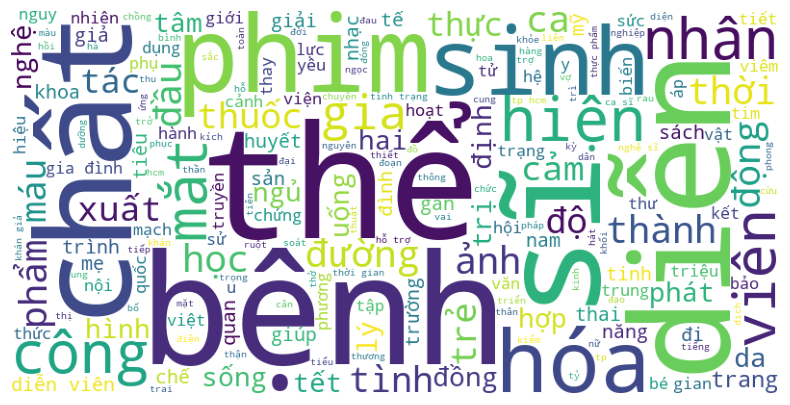

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Lấy tổng TF-IDF của mỗi từ
import numpy as np
tfidf_scores = np.asarray(X_text.sum(axis=0)).ravel()

# Lấy vocabulary
words = vectorizer.get_feature_names_out()

# Tạo dictionary word → score
word_scores = dict(zip(words, tfidf_scores))

# WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False
).generate_from_frequencies(word_scores)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()

4. Mã hóa nhãn các nhóm

In [14]:
from sklearn.preprocessing import LabelEncoder

# Khởi tạo encoder
label_encoder = LabelEncoder()

# Encode cột group
y = label_encoder.fit_transform(df["group"])

# Kiểm tra mapping
print("Label mapping:")
for label, index in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(label, "->", index)


Label mapping:
Giải trí -> 0
Khác -> 1
Sức khỏe -> 2


5. Xem phân bố trong không gian vector

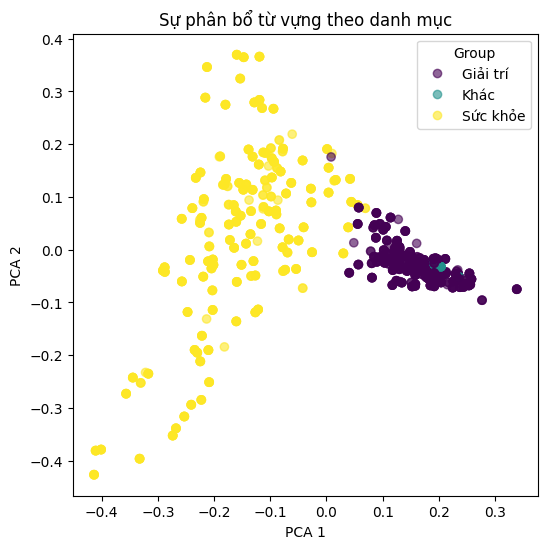

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# chuyển sparse -> dense
X_dense = X_text.toarray()

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

# encode group thành số
groups = df["group"].astype("category")
colors = groups.cat.codes

# plot
plt.figure(figsize=(6,6))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=colors,
    alpha=0.6
)

# legend
handles, _ = scatter.legend_elements()
plt.legend(handles, list(groups.cat.categories), title="Group")

plt.title("Sự phân bổ từ vựng theo danh mục")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Sau khi thực hiện xong việc trực quan, ta nhận thấy các vector được phân nhóm khá rõ rệt

Vậy ta sẽ thực hiện bài toán theo hướng `classification` hay còn gọi là bài toán phân loại là phù hợp